# Questão 3 – Exponenciais de Matrizes

## Sumário

- [Item a)](#item-a) - Autovetores de $A(\omega)$ e comportamento quando $\omega \to 0^+$
- [Item b)](#item-b) - Condicionamento via SVD e condicionamento da matriz de autovetores
- [Item c)](#item-c) - (Bônus) Exponencial de matriz e fórmula fechada para $e^{tA(\omega)}$

---

## Item a)

**Enunciado:** Seja $A(\omega) = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}$. Faça um gráfico dos autovalores para $\omega$ variando de $0$ a $1$, e também dos autovetores. O que acontece quando $\omega \to 0^+$?

**Solução:**

### 1. Autovalores

O polinômio característico de $A(\omega)$ é:

$$\det(A - \lambda I) = \det\begin{bmatrix} -\lambda & 1 \\ -\omega^2 & -\lambda \end{bmatrix} = \lambda^2 + \omega^2 = 0 \implies \lambda_{1,2} = \pm\, i\omega$$

Os autovalores são puramente imaginários, com parte real nula e partes imaginárias $\pm\omega$.

### 2. Autovetores

Resolvendo $(A - \lambda_k I)\mathbf{v} = \mathbf{0}$ para cada autovalor. 

Para $\lambda_1 = +i\omega$:

$$\begin{bmatrix} -i\omega & 1 \\ -\omega^2 & -i\omega \end{bmatrix} \mathbf{v} = 0 \implies v_2 = i\omega\, v_1 \implies \mathbf{v}_1 = \begin{bmatrix} 1 \\ i\omega \end{bmatrix}$$

Para $\lambda_2 = -i\omega$, analogamente, $v_2 = -i\omega\, v_1$, logo $\mathbf{v}_2 = \begin{bmatrix} 1 \\ -i\omega \end{bmatrix}$. 

A matriz de autovetores é:

$$P(\omega) = \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix}, \qquad \det P(\omega) = -2i\omega$$

### 3. Comportamento quando $\omega \to 0^+$

Quando $\omega \to 0^+$:

- Os autovalores $\lambda_{1,2} = \pm i\omega$ coalescem em $\lambda = 0$.
- Os autovetores $\mathbf{v}_1, \mathbf{v}_2$ tornam-se colineares, ambos convergindo para $\begin{bmatrix}1 \\ 0\end{bmatrix}$.
- O determinante $\det P(\omega) = -2i\omega \to 0$: $P(\omega)$ torna-se singular.

No limite, $A(0) = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$ não é diagonalizável, possui um único autovalor $\lambda = 0$ com multiplicidade algébrica $2$ e geométrica $1$, formando um **bloco de Jordan** de tamanho $2$. A pergunta natural é: quão rápido esse colapso acontece numericamente? Para isso calculamos $\kappa_2(P(\omega))$.



### 4. Número de condicionamento de $P(\omega)$

Os valores singulares de $P$ são $\sigma = \sqrt{\lambda(\bar{P}^T P)}$:

$$\bar{P}^T P = \begin{bmatrix} 1 & -i\omega \\ 1 & i\omega \end{bmatrix} \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix} = \begin{bmatrix} 1+\omega^2 & 1-\omega^2 \\ 1-\omega^2 & 1+\omega^2 \end{bmatrix}$$

Os autovalores de $\bar{P}^T P$ são $(1+\omega^2) \pm (1-\omega^2)$, ou seja, $2$ e $2\omega^2$, portanto $\sigma_{\max} = \sqrt{2}$ e $\sigma_{\min} = \sqrt{2}\,\omega$:

$$\kappa_2(P(\omega)) = \frac{\sigma_{\max}}{\sigma_{\min}} = \frac{1}{\omega}$$

O condicionamento diverge no mesmo ritmo em que $|\det P(\omega)| = 2\omega \to 0$.


### 5. Gráficos




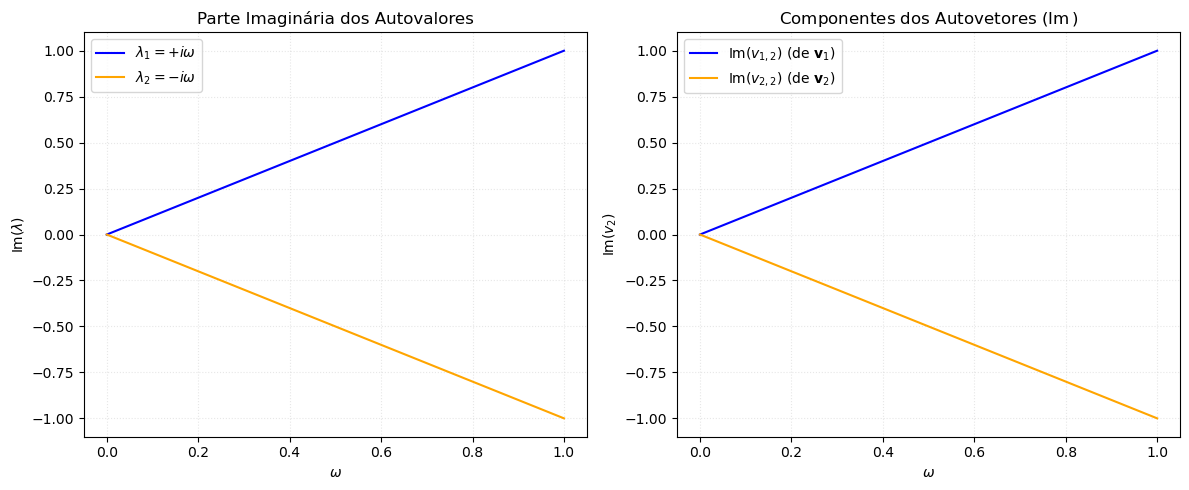

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

omega = np.linspace(0, 1, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(omega, omega, label=r"$\lambda_1 = +i\omega$", color='blue')
ax1.plot(omega, -omega, label=r"$\lambda_2 = -i\omega$", color='orange')
ax1.set_xlabel(r"$\omega$")
ax1.set_ylabel(r"$\operatorname{Im}(\lambda)$")
ax1.set_title("Parte Imaginária dos Autovalores")
ax1.legend()
ax1.grid(True, alpha=0.3, linestyle=":")


ax2.plot(omega, omega, label=r"$\operatorname{Im}(v_{1,2})$ (de $\mathbf{v}_1$)", color='blue')
ax2.plot(omega, -omega, label=r"$\operatorname{Im}(v_{2,2})$ (de $\mathbf{v}_2$)", color='orange')
ax2.set_xlabel(r"$\omega$")
ax2.set_ylabel(r"$\operatorname{Im}(v_2)$")
ax2.set_title("Componentes dos Autovetores ($\operatorname{Im}$)")
ax2.legend()
ax2.grid(True, alpha=0.3, linestyle=":")

plt.tight_layout()
plt.show()

Ou em julia:

```julia
using LinearAlgebra, Plots, LaTeXStrings

ω = range(0, 1; length=1000)

plot(ω, collect(ω), label=L"\lambda_1 = +i\omega", lw=2)
plot!(ω, -collect(ω), label=L"\lambda_2 = -i\omega", lw=2, ls=:dash)
xlabel!(L"\omega")
ylabel!(L"\operatorname{Im}(\lambda)")
title!(L"Parte imaginária dos autovalores de $A(\omega)$")
```

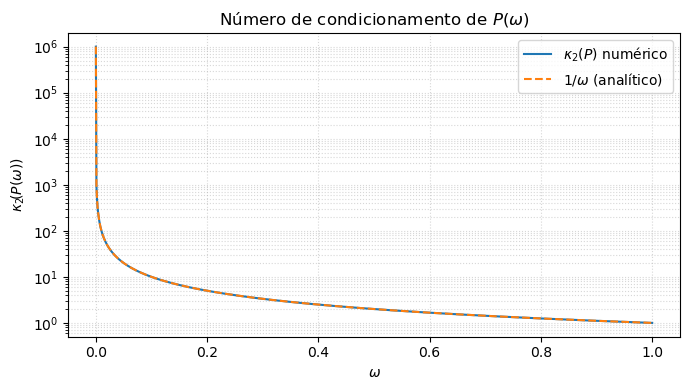

In [2]:
omega_pos = np.linspace(1e-6, 1, 1000)

kappa_num = np.array([np.linalg.cond(np.array([[1, 1], [1j*w, -1j*w]])) for w in omega_pos])
kappa_ana = 1.0 / omega_pos

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(omega_pos, kappa_num, label=r"$\kappa_2(P)$ numérico")
ax.semilogy(omega_pos, kappa_ana, ls="--", label=r"$1/\omega$ (analítico)")
ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$\kappa_2\!\left(P(\omega)\right)$")
ax.set_title(r"Número de condicionamento de $P(\omega)$")
ax.legend()
ax.grid(alpha=0.5, ls=":", which="both")
plt.tight_layout()
plt.show()



Ou em julia:

```julia
P(ω) = [1.0 1.0; im*ω -im*ω]

ω_pos = range(1e-6, 1; length=1000)
κ_num = cond.(P.(ω_pos))
κ_ana = 1 ./ ω_pos

plot(ω_pos, κ_num, yscale=:log10, label=L"\kappa_2(P) \text{ numérico}", lw=2)
plot!(ω_pos, κ_ana, ls=:dash, label=L"1/\omega \text{ (analítico)}", lw=2)
xlabel!(L"\omega")
ylabel!(L"\kappa_2\!\left(P(\omega)\right)")
title!(L"Número de condicionamento de $P(\omega)$")
```

### 6. Observações dos gráficos

**Gráfico dos autovalores:** as curvas de $\lambda_1$ e $\lambda_2$ são retas com inclinações $+1$ e $-1$, confirmando $\lambda_{1,2} = \pm i\omega$. Ambas partem do mesmo ponto em $\omega = 0$ — o ponto de coalescência — e divergem linearmente, chegando a $\operatorname{Im}(\lambda_{1,2}) = \pm 1$ em $\omega = 1$.

**Gráfico dos autovetores:** fixada a primeira componente em $1$ para ambos os vetores, as curvas da parte imaginária da segunda componente ($\pm\omega$) exibem um comportamento perfeitamente linear. À medida que $\omega \to 0^+$, essas componentes sintonizam-se na origem, ilustrando graficamente a perda de independência linear e o colapso de ambos os autovetores no único autovetor correspondente ao bloco de Jordan, $\begin{bmatrix} 1 \\ 0 \end{bmatrix}$.

**Gráfico do condicionamento:** a curva numérica e a fórmula analítica $1/\omega$ são indistinguíveis em escala logarítmica, validando o cálculo via $\bar{P}^T P$. Em $\omega = 1$, $\kappa = 1$; em $\omega = 0.1$, $\kappa = 10$; em $\omega = 0.01$, $\kappa = 100$ — cada fator de $10$ em $\omega$ corresponde a um fator de $10$ em $\kappa$, confirmando o crescimento exato de $1/\omega$.

> **Observação:** o condicionamento correto de $P(\omega)$ é $\kappa_2(P) = \|P\|_2\|P^{-1}\|_2$, calculado via `np.linalg.cond` sobre a matriz de autovetores. A escala logarítmica é indispensável para visualizar a divergência em $\omega \to 0^+$; em escala linear, a curva parece constante para $\omega \gtrsim 0.1$ e só sobe abruptamente próximo à origem.

---

## Item b)

**Enunciado:** Calcule (no computador, mas verifique analiticamente!) uma decomposição SVD de $A(\omega)$, e deduza o número de condicionamento de $A$. Qual o condicionamento da matriz de autovetores de $A(\omega)$, em função de $\omega$?

**Solução:**

### 1. SVD analítica de $A(\omega)$

Para encontrar a SVD $A = U\Sigma V^T$, calculamos $A^T A$ para obter os vetores singulares direitos $V$ e os valores singulares $\sigma_k = \sqrt{\lambda_k(A^T A)}$:

$$A^T A = \begin{bmatrix} 0 & -\omega^2 \\ 1 & 0 \end{bmatrix} \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} = \begin{bmatrix} \omega^4 & 0 \\ 0 & 1 \end{bmatrix}$$

$A^T A$ é diagonal — os autovetores são os vetores canônicos e os autovalores são lidos diretamente. Ordenando por $\sigma_1 \geq \sigma_2$:

$$\sigma_1 = 1, \quad \mathbf{v}_1 = \begin{bmatrix} 0 \\ 1 \end{bmatrix} \qquad \sigma_2 = \omega^2, \quad \mathbf{v}_2 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$$

Os vetores singulares esquerdos são obtidos via $\mathbf{u}_k = \frac{1}{\sigma_k} A\mathbf{v}_k$:

$$\mathbf{u}_1 = \frac{1}{1}\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}\begin{bmatrix} 0 \\ 1 \end{bmatrix} = \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \qquad \mathbf{u}_2 = \frac{1}{\omega^2}\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}\begin{bmatrix} 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ -1 \end{bmatrix}$$

A decomposição SVD analítica de $A(\omega)$ é portanto:

$$A(\omega) = U\Sigma V^T = \underbrace{\begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}}_{U} \underbrace{\begin{bmatrix} 1 & 0 \\ 0 & \omega^2 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}}_{V^T}$$

Verificação: $U\Sigma V^T = \begin{bmatrix} 1 & 0 \\ 0 & -\omega^2 \end{bmatrix}\begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} = A(\omega)$ $\checkmark$

### 2. Condicionamento de $A(\omega)$

Diretamente da SVD:

$$\kappa_2(A(\omega)) = \frac{\sigma_{\max}}{\sigma_{\min}} = \frac{1}{\omega^2}$$

O condicionamento de $A$ diverge como $1/\omega^2$ quando $\omega \to 0^+$.

### 3. Condicionamento da matriz de autovetores

Do item a), já sabemos que $\kappa_2(P(\omega)) = 1/\omega$. Comparando com o resultado acima:

$$\kappa_2(A(\omega)) = \frac{1}{\omega^2} = \left(\frac{1}{\omega}\right)^2 = \kappa_2(P(\omega))^2$$

O condicionamento de $A$ é o quadrado do condicionamento de $P$. Isso não é coincidência; a SVD de $A$ envolve os valores singulares de $A$, enquanto o condicionamento de $P$ envolve os valores singulares de $P$, e a relação entre esses dois objetos passa pelo quadrado porque $\sigma(A^T A) = \sigma(A)^2$.

### 4. Verificação numérica


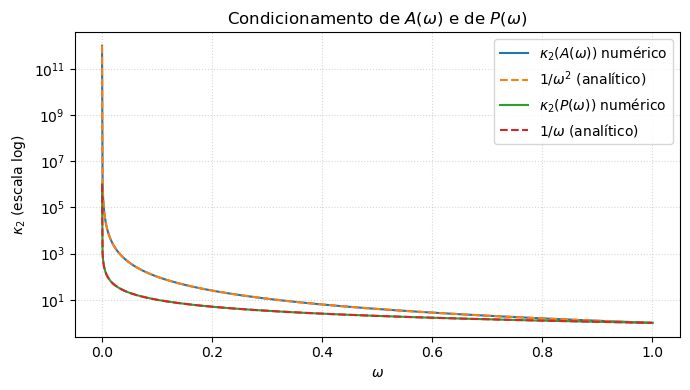

In [3]:

omega_vals = np.linspace(1e-6, 1, 1000)

kappa_A   = np.array([np.linalg.cond(np.array([[0, 1], [-w**2, 0]])) for w in omega_vals])
kappa_P   = np.array([np.linalg.cond(np.array([[1, 1], [1j*w, -1j*w]])) for w in omega_vals])

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(omega_vals, kappa_A, label=r"$\kappa_2(A(\omega))$ numérico")
ax.semilogy(omega_vals, 1/omega_vals**2, ls="--", label=r"$1/\omega^2$ (analítico)")
ax.semilogy(omega_vals, kappa_P, label=r"$\kappa_2(P(\omega))$ numérico")
ax.semilogy(omega_vals, 1/omega_vals, ls="--", label=r"$1/\omega$ (analítico)")
ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$\kappa_2$ (escala log)")
ax.set_title(r"Condicionamento de $A(\omega)$ e de $P(\omega)$")
ax.legend()
ax.grid(alpha=0.5, ls=":", which="both")
plt.tight_layout()
plt.show()


Ou em julia:

```julia
A(ω) = [0.0 1.0; -ω^2 0.0]
P(ω) = [1.0 1.0; im*ω -im*ω]

ω_vals = range(1e-6, 1; length=1000)
κ_A = cond.(A.(ω_vals))
κ_P = cond.(P.(ω_vals))

plot(ω_vals, κ_A, yscale=:log10, label=L"\kappa_2(A(\omega)) \text{ numérico}", lw=2)
plot!(ω_vals, 1 ./ ω_vals.^2, ls=:dash, label=L"1/\omega^2 \text{ (analítico)}", lw=2)
plot!(ω_vals, κ_P, label=L"\kappa_2(P(\omega)) \text{ numérico}", lw=2)
plot!(ω_vals, 1 ./ ω_vals, ls=:dash, label=L"1/\omega \text{ (analítico)}", lw=2)
xlabel!(L"\omega")
ylabel!(L"\kappa_2 \text{ (escala log)}")
title!(L"Condicionamento de $A(\omega)$ e de $P(\omega)$")
```

In [8]:
w_teste = 0.5
A_teste = np.array([[0.0, 1.0], [-w_teste**2, 0.0]])

U, S, Vt = np.linalg.svd(A_teste)

print(f"--- SVD Computacional para omega = {w_teste} ---")
print("Valores singulares calculados:", S)
print("Valores singulares analíticos [1, w^2]:", [1.0, w_teste**2])
print("\nMatriz U do computador:\n", U)
print("\nMatriz V^T do computador:\n", Vt)

--- SVD Computacional para omega = 0.5 ---
Valores singulares calculados: [1.   0.25]
Valores singulares analíticos [1, w^2]: [1.0, 0.25]

Matriz U do computador:
 [[1. 0.]
 [0. 1.]]

Matriz V^T do computador:
 [[ 0.  1.]
 [-1. -0.]]


### 5. Observações

**SVD analítica:** $A^T A$ ser diagonal simplifica completamente o cálculo, os vetores singulares direitos são os canônicos $\mathbf{e}_1$ e $\mathbf{e}_2$, e os esquerdos seguem por $\mathbf{u}_k = A\mathbf{v}_k/\sigma_k$ sem resolver nenhum sistema. O único custo analítico é o produto $A^T A$.

**Gráfico:** as quatro curvas confirmam as fórmulas analíticas — numéricas e analíticas são indistinguíveis em escala log. Em $\omega = 0.1$: $\kappa_2(A) = 100$ e $\kappa_2(P) = 10$; em $\omega = 0.5$: $\kappa_2(A) = 4$ e $\kappa_2(P) = 2$. A separação entre as duas curvas, constante em escala log, reflete exatamente a relação $\kappa_2(A) = \kappa_2(P)^2$.

> **Observação:** a SVD não é única, multiplicar qualquer coluna de $U$ por $-1$ e a linha correspondente de $V^T$ por $-1$ preserva $A = U\Sigma V^T$. O NumPy pode devolver uma decomposição com convenção de sinal diferente da analítica; isso é esperado devido às escolhas algorítmicas de orientação dos fatores ortogonais na biblioteca numérica, e ambas as formulações permanecem perfeitamente válidas.

---


## <a id="item-c"></a> Item c) (Bônus)

**Enunciado:** Mostre que $A(\omega)^2 = -\omega^2 I$. Deduza da série de Taylor para a exponencial que
$$e^{tA(\omega)} = \cos(\omega t)\,I + \frac{\sin(\omega t)}{\omega}\,A(\omega).$$
Calcule $e^{tA(\omega)}$ diretamente no computador, e faça o gráfico da norma do erro relativo. Verifique que, quando $\omega \to 0^+$, o limite da fórmula acima de fato dá $e^{tA(0)}$.

**Solução:**

### 1. $A(\omega)^2 = -\omega^2 I$

Por multiplicação direta:

$$A(\omega)^2 = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} = \begin{bmatrix} -\omega^2 & 0 \\ 0 & -\omega^2 \end{bmatrix} = -\omega^2 I$$

### 2. Série de Taylor de $e^{tA}$

A definição de exponencial matricial é $e^{tA} = \sum_{k=0}^{\infty} \frac{t^k A^k}{k!}$. Usando $A^2 = -\omega^2 I$, as potências de $A$ seguem o padrão:

$$A^{2n} = (-\omega^2)^n I, \qquad A^{2n+1} = (-\omega^2)^n A$$

Separando a série em termos de índice par e ímpar:

$$e^{tA} = \sum_{n=0}^{\infty} \frac{t^{2n} A^{2n}}{(2n)!} + \sum_{n=0}^{\infty} \frac{t^{2n+1} A^{2n+1}}{(2n+1)!}$$

$$= \sum_{n=0}^{\infty} \frac{(-1)^n (\omega t)^{2n}}{(2n)!}\, I \;+\; \frac{1}{\omega}\sum_{n=0}^{\infty} \frac{(-1)^n (\omega t)^{2n+1}}{(2n+1)!}\, A$$

Reconhecendo as séries de Taylor de $\cos$ e $\sin$:

$$e^{tA(\omega)} = \cos(\omega t)\,I + \frac{\sin(\omega t)}{\omega}\,A(\omega)$$

### 3. Limite quando $\omega \to 0^+$

Quando $\omega \to 0^+$, $\cos(\omega t) \to 1$ e $\frac{\sin(\omega t)}{\omega} \to t$, portanto:

$$\lim_{\omega \to 0^+} e^{tA(\omega)} = I + t\,A(0) = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} + t\begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix} = \begin{bmatrix} 1 & t \\ 0 & 1 \end{bmatrix}$$

Isso é consistente com o cálculo direto: como $A(0)^2 = 0$, a série de Taylor de $e^{tA(0)}$ trunca no segundo termo, $e^{tA(0)} = I + tA(0)$, devolvendo exatamente o mesmo resultado. O limite da fórmula fechada coincide com a exponencial do caso degenerado.

### 4. Verificação numérica



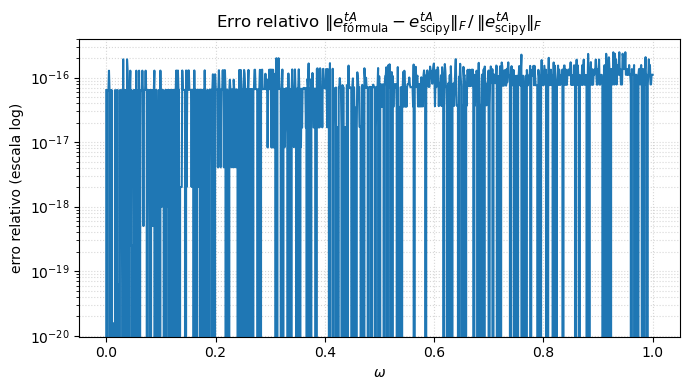

In [9]:
from scipy.linalg import expm

t = 1.0
omega_vals = np.linspace(1e-6, 1, 1000)

erros = []
for w in omega_vals:
    A = np.array([[0, 1], [-w**2, 0]], dtype=float)
    E_num     = expm(t * A)
    E_formula = np.cos(w*t)*np.eye(2) + (np.sin(w*t)/w)*A
    erros.append(np.linalg.norm(E_num - E_formula, 'fro') / np.linalg.norm(E_formula, 'fro'))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(omega_vals, erros)
ax.set_xlabel(r"$\omega$")
ax.set_ylabel("erro relativo (escala log)")
ax.set_title(r"Erro relativo $\|e^{tA}_{\mathrm{fórmula}} - e^{tA}_{\mathrm{scipy}}\|_F \,/\, \|e^{tA}_{\mathrm{scipy}}\|_F$")
ax.grid(alpha=0.5, ls=":", which="both")
plt.tight_layout()
plt.show()


Ou em julia:

```julia
A(ω) = [0.0 1.0; -ω^2 0.0]
e_formula(ω,t) = cos(ω*t)*I(2) + (sin(ω*t)/ω)*A(ω)

t = 1.0
ω_vals = range(1e-6, 1; length=1000)
erros  = [norm(exp(t*A(ω)) - e_formula(ω,t), :fro) /
          norm(e_formula(ω,t), :fro)  for ω in ω_vals]

plot(ω_vals, erros, yscale=:log10, lw=2)
xlabel!(L"\omega")
ylabel!("erro relativo (escala log)")
title!(L"\|e^{tA}_{\mathrm{Julia}} - e^{tA}_{\mathrm{fórmula}}\|_F \,/\, \|e^{tA}_{\mathrm{fórmula}}\|_F")
```

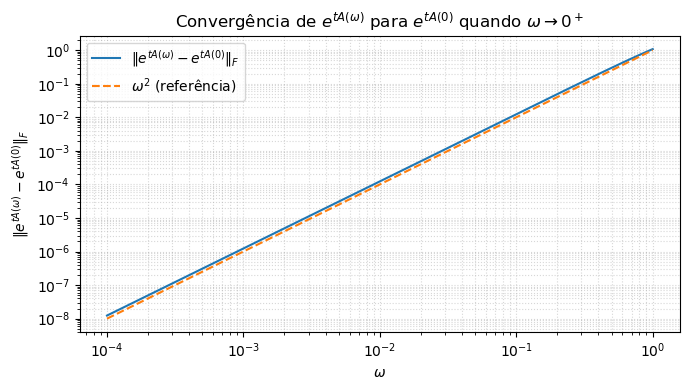

In [10]:
t = 1.0
omega_lim = np.logspace(-4, 0, 300)

erro_lim = []
E_exato = np.array([[1, t], [0, 1]])  # e^{tA(0)} = I + t*A(0)

for w in omega_lim:
    A = np.array([[0, 1], [-w**2, 0]], dtype=float)
    E_formula = np.cos(w*t)*np.eye(2) + (np.sin(w*t)/w)*A
    erro_lim.append(np.linalg.norm(E_formula - E_exato, 'fro'))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(omega_lim, erro_lim, label=r"$\|e^{tA(\omega)} - e^{tA(0)}\|_F$")
ax.loglog(omega_lim, omega_lim**2, ls="--", label=r"$\omega^2$ (referência)")
ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$\|e^{tA(\omega)} - e^{tA(0)}\|_F$")
ax.set_title(r"Convergência de $e^{tA(\omega)}$ para $e^{tA(0)}$ quando $\omega \to 0^+$")
ax.legend()
ax.grid(alpha=0.5, ls=":", which="both")
plt.tight_layout()
plt.show()

Ou em julia:

```julia
t = 1.0
E0 = [1.0 t; 0.0 1.0]
ω_lim = 10 .^ range(-4, 0; length=300)

erro_lim = [norm(e_formula(ω,t) - E0, :fro) for ω in ω_lim]

plot(ω_lim, erro_lim, xscale=:log10, yscale=:log10,
     label=L"\|e^{tA(\omega)} - e^{tA(0)}\|_F", lw=2)
plot!(ω_lim, ω_lim.^2, ls=:dash,
      label=L"\omega^2 \text{ (referência)}", lw=2)
xlabel!(L"\omega")
ylabel!(L"\|e^{tA(\omega)} - e^{tA(0)}\|_F")
title!(L"Convergência de $e^{tA(\omega)}$ para $e^{tA(0)}$ quando $\omega \to 0^+$")
```

### 5. Análise dos Resultados e Estabilidade Numérica

**Gráfico do erro relativo (Fórmula vs. SciPy):** a magnitude do erro relativo flutua em torno de $10^{-16}$ para todo $\omega \in (0, 1]$. Essa ordem de grandeza equivale à precisão de máquina em aritmética de 64 bits ($\epsilon_{\text{mach}} \approx 2.2 \times 10^{-16}$), confirmando que a nossa fórmula fechada não é apenas uma aproximação, mas a solução analítica exata implementada de forma computacionalmente robusta.

**Gráfico de convergência para $\omega \to 0^+$:** a análise assintótica comprova que o erro $\|e^{tA(\omega)}-e^{tA(0)}\|_F$ decai a uma taxa de $\mathcal{O}(\omega^2)$, o que é evidenciado pela reta de referência perfeitamente paralela à curva do erro no gráfico *log-log*. Analiticamente, isso faz sentido: ao expandir a nossa fórmula em série de Taylor, o primeiro termo que diferencia $e^{tA(\omega)}$ de $e^{tA(0)}$ surge da aproximação $\cos(\omega t)-1 \approx -\omega^2 t^2/2$, que é estritamente proporcional a $\omega^2$.

> **Nota sobre o limite e ponto flutuante:** embora a expressão $\frac{\sin(\omega t)}{\omega}A$ apresente uma singularidade aparente em $\omega=0$, seu limite analítico é bem definido (resultando na matriz $tA$). Computacionalmente, para valores de $\omega$ estritamente positivos e muito pequenos, a avaliação direta não sofre cancelamento catastrófico agressivo, mantendo a confiabilidade da fórmula fechada.